# NOAA Data Ingestion

This notebook produces the cleaned per-city CSVs that feed the OU pipeline.

In [1]:
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import ROOT, CITIES_RAW_DIR   

RAW_PATH     = ROOT / "data" / "raw_data" / "4333721.csv"
COMMON_START = pd.Timestamp("1950-01-01")
COMMON_END   = pd.Timestamp("2026-01-01")

STATION_TO_CITY = {
    "USW00003927": "Dallas",      "USW00014739": "Boston",
    "USW00014810": "Chicago",     "USW00014922": "Minneapolis",
    "USW00014947": "Minneapolis", "USW00023174": "Los_Angeles",
    "USW00024233": "Seattle",     "USW00094728": "New_York",
    "USW00094846": "Chicago",
}

# Academic plot style shared across project notebooks
plt.rcParams.update({
    "font.family": "serif", "font.size": 10, "axes.titlesize": 11,
    "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})
CITY_COLORS = {
    "Chicago": "#1f4e79", "New_York": "#c0392b", "Boston": "#2ca02c",
    "Minneapolis": "#9467bd", "Dallas": "#d4882b", "Los_Angeles": "#7f7f7f",
    "Seattle": "#17becf",
}

## Extraction

Only re-run when the raw file changes (new NOAA order). If the bulk file is absent, the cell
is skipped gracefully and we work with the CSVs already present in `data/cities/`.

In [2]:
def first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else pd.NA

if RAW_PATH.exists():
    raw = pd.read_csv(RAW_PATH)
    df = raw[raw["STATION"].isin(STATION_TO_CITY)].copy()
    df["CITY"] = df["STATION"].map(STATION_TO_CITY)
    df["DATE"] = pd.to_datetime(df["DATE"])

    # tenths of °C -> °C (heuristic: absolute median > 80)
    for col in ("TAVG", "TMIN", "TMAX"):
        if col in df.columns and df[col].abs().median() > 80:
            df[col] = df[col] / 10.0

    # reconstruct TAVG when missing
    if "TAVG" not in df.columns:
        df["TAVG"] = pd.NA
    mask = df["TAVG"].isna() & df["TMIN"].notna() & df["TMAX"].notna()
    df.loc[mask, "TAVG"] = (df.loc[mask, "TMIN"] + df.loc[mask, "TMAX"]) / 2

    # one row per (city, date), first non-missing station value wins
    city_df = (df.sort_values(["CITY", "DATE"])
                 .groupby(["CITY", "DATE"], as_index=False)
                 .agg({c: first_non_null for c in ("TAVG", "TMIN", "TMAX")}))

    CITIES_RAW_DIR.mkdir(parents=True, exist_ok=True)
    kept, discarded = [], []
    for city, g in city_df.groupby("CITY"):
        if not (g["DATE"].min() <= COMMON_START and g["DATE"].max() >= COMMON_END):
            discarded.append((city, g["DATE"].min().date(), g["DATE"].max().date()))
            continue
        g = g[(g["DATE"] >= COMMON_START) & (g["DATE"] <= COMMON_END)].copy()
        for col in ("TAVG", "TMIN", "TMAX"):
            g[col] = pd.to_numeric(g[col], errors="coerce").round(3)
        g[["DATE", "TAVG", "TMIN", "TMAX"]].to_csv(CITIES_RAW_DIR / f"{city}.csv", index=False)
        kept.append((city, len(g)))

    print("Kept:", ", ".join(f"{c} ({n:,})" for c, n in sorted(kept)))
    if discarded:
        print("Discarded (insufficient coverage):",
              ", ".join(f"{c} [{s} → {e}]" for c, s, e in sorted(discarded)))
else:
    print(f"Raw file missing ({RAW_PATH.name}). Using existing CSVs in {CITIES_RAW_DIR}.")

Kept: Boston (27,760), Chicago (27,760), Dallas (27,758), Los_Angeles (27,760), Minneapolis (27,760), New_York (27,760), Seattle (27,760)


## Quality control: coverage and missing data

Two checks before feeding the OU pipeline: 
- (1) every city covers the same window
- (2) the share of days missing `TMIN`/`TMAX` stays marginal

In [3]:
files = sorted(CITIES_RAW_DIR.glob("*.csv"))
rows = []
for f in files:
    d = pd.read_csv(f, parse_dates=["DATE"])
    rows.append({
        "city": f.stem,
        "start": d["DATE"].min().date(), "end": d["DATE"].max().date(),
        "n_days": len(d),
        "%NaN TMIN": round(d["TMIN"].isna().mean() * 100, 2),
        "%NaN TMAX": round(d["TMAX"].isna().mean() * 100, 2),
        "%NaN TAVG": round(d["TAVG"].isna().mean() * 100, 2),
    })
pd.DataFrame(rows).set_index("city")

,start,end,n_days,%NaN TMIN,%NaN TMAX,%NaN TAVG
city,,,,,,
Boston,1950-01-01,2026-01-01,27760,0.00,0.00,0.00
Chicago,1950-01-01,2026-01-01,27760,0.00,0.00,0.00
Dallas,1950-01-01,2026-01-01,27758,4.36,4.36,4.36
Los_Angeles,1950-01-01,2026-01-01,27760,0.00,0.00,0.00
Minneapolis,1950-01-01,2026-01-01,27760,0.00,0.00,0.00
New_York,1950-01-01,2026-01-01,27760,0.00,0.00,0.00
Seattle,1950-01-01,2026-01-01,27760,0.00,0.00,0.00


Verdict: the window is consistent across all cities and the share of missing `TMIN`/`TMAX` stays marginal, so the cleaned CSVs are ready for the OU pipeline.

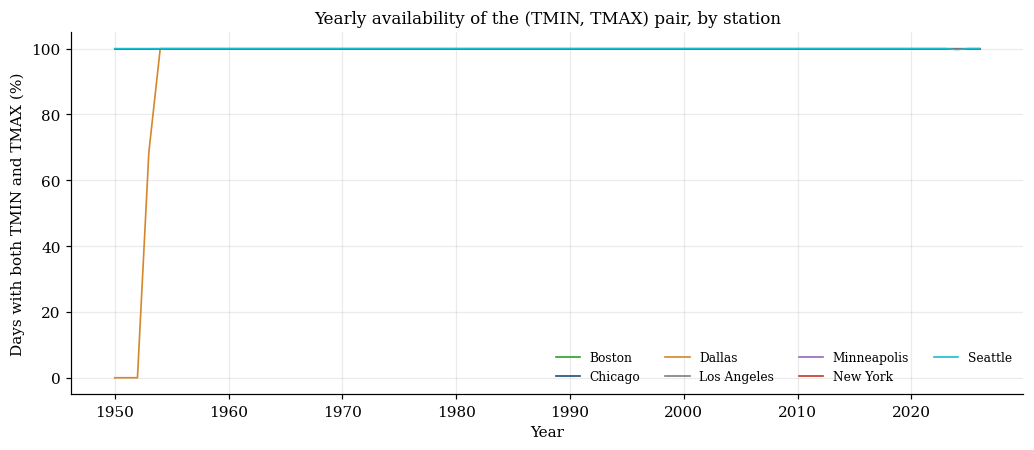

In [4]:
# Yearly availability of the (TMIN, TMAX) pair, source quality per city.
# (A case where showing all 7 cities is the point: data gaps are station-specific.)
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for f in files:
    d = pd.read_csv(f, parse_dates=["DATE"])
    avail = (d.assign(ok=d["TMIN"].notna() & d["TMAX"].notna())
               .groupby(d["DATE"].dt.year)["ok"].mean() * 100)
    ax.plot(avail.index, avail.values, lw=1.1, label=f.stem.replace("_", " "),
            color=CITY_COLORS.get(f.stem, "grey"))
ax.set_xlabel("Year"); ax.set_ylabel("Days with both TMIN and TMAX (%)")
ax.set_title("Yearly availability of the (TMIN, TMAX) pair, by station")
ax.set_ylim(bottom=min(80, ax.get_ylim()[0]))
ax.legend(frameon=False, ncols=4, fontsize=8, loc="lower right")
fig.tight_layout()